# Predicción de satisfacción de clientes en vuelos
## Modelo Fase 1 - Pre-vuelo

Este modelo tiene como objetivo predecir la satisfacción del pasajero al momento de realizar la reserva (pre-vuelo), utilizando únicamente variables demográficas y de reserva que están disponibles antes del abordaje del vuelo.

---
## Importación de librerías

In [1]:
from pathlib import Path
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display
from sklearn.metrics import log_loss, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import learning_curve
import warnings

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
warnings.filterwarnings('ignore')

---
## Carga de datos

In [2]:
def load_airline_data():
    csv_path = Path.home() / "Downloads" / "Invistico_Airline.csv"
    
    if not csv_path.is_file():
        csv_path.parent.mkdir(parents=True, exist_ok=True)
        url = "https://github.com/AgustinaHourcade/airline-passenger-satisfaction/blob/main/Invistico_Airline.csv"
        urllib.request.urlretrieve(url, csv_path)
        
    return pd.read_csv(csv_path)

df = load_airline_data()
print(f"Forma del dataset: {df.shape}")

Forma del dataset: (129880, 23)


In [3]:
df['Satisfaction_bin'] = (df['satisfaction'] == 'satisfied').astype(int)

PRE_FLIGHT_FEATURES = [
    'Age', 'Flight Distance',
    'Gender', 'Customer Type', 'Type of Travel', 'Class'
]

BINARY_MAP = {
    'Gender':         {'Female': 1, 'Male': 0},
    'Customer Type':  {'Loyal Customer': 1, 'disloyal Customer': 0},
    'Type of Travel': {'Business travel': 1, 'Personal Travel': 0},
}

df_model = df.copy()
for col, mapping in BINARY_MAP.items():
    df_model[col] = df_model[col].map(mapping)

X = df_model[PRE_FLIGHT_FEATURES].copy()
y = df_model['Satisfaction_bin']

print(f"Shape de X: {X.shape}")
print(f"Distribución del target — satisfied: {y.mean()*100:.1f}%  |  dissatisfied: {(1-y.mean())*100:.1f}%")
display(X.head(5))

Shape de X: (129880, 6)
Distribución del target — satisfied: 54.7%  |  dissatisfied: 45.3%


,Age,Flight Distance,Gender,Customer Type,Type of Travel,Class
0,65,265,1,1,0,Eco
1,47,2464,0,1,0,Business
2,15,2138,1,1,0,Eco
3,60,623,1,1,0,Eco
4,70,354,1,1,0,Eco


---
## División Train / Test (Hold-Out)
**80 % entrenamiento - 20 % prueba**, con estratificación para preservar la proporción original de clases (≈54.7 % satisfechos / 45.3 % insatisfechos) en ambos conjuntos.

**Prevención de Fugas (Data Leakage)**: Es crucial destacar que esta división se realiza antes de cualquier preprocesamiento. Al asegurar que no haya fuga de información del conjunto de test hacia el de entrenamiento, garantizamos que las métricas de evaluación reflejarán el verdadero rendimiento del modelo ante datos no vistos.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Tamaño Train: {X_train.shape[0]:,} registros")
print(f"Tamaño Test: {X_test.shape[0]:,} registros")

Tamaño Train: 103,904 registros
Tamaño Test: 25,976 registros


La división elegida hold-out 80/20 deja un conjunto de entrenamiento de 103,904 instancias y uno de prueba de 25,976. Con esos volúmenes, se puede hipotetizar que ambos subconjuntos son estadísticamente representativos de la distribución original.

El punto más importante del diseño es la estratificación. Al forzar que ambas particiones mantengan la misma proporción de clases (≈54.7 % / 45.3 %), se evita que un split aleatorio desfavorable termine concentrando la clase minoritaria en el set de entrenamiento o en el de prueba. Esto es especialmente relevante para el Modelo Pre-vuelo: dado que sus features tienen menor poder discriminativo que las puntuaciones de servicio, se postula que ese modelo es más sensible a cualquier desbalance espurio en la proporción de clases que llegue al entrenamiento.

Una proporción 54/46 es moderada, lejos del umbral donde técnicas como SMOTE o submuestreo se vuelven necesarias. Sin embargo, se hipotetiza que incluso este desbalance leve puede inclinar al clasificador a favorecer la clase mayoritaria en escenarios donde la señal predictiva es débil, algo que habría que monitorear en el recall de la clase "insatisfecho" del Modelo Pre-vuelo.

---
## Pipelines con ColumnTransformer

In [ ]:
NUMERIC_FEATURES = ['Age', 'Flight Distance']
ONEHOT_FEATURES = ['Class']

preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), NUMERIC_FEATURES),
        ('ohe_class', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ONEHOT_FEATURES),
    ],
    remainder='passthrough'
)

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, random_state=42, solver='lbfgs'))
])

pipe_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42))
])

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

---
## Selección de Modelos y Búsqueda de Hiperparámetros

Para la selección de modelos se evaluaron tres algoritmos de clasificación: Logistic Regression, Decision Tree y Random Forest. Se hipotetiza que cubrir el espectro desde un modelo lineal hasta uno de ensamble permite diagnosticar si el problema de clasificación tiene una frontera de decisión aproximadamente lineal o si requiere mayor capacidad de representación no lineal.

### Estrategia de Validación Cruzada

La evaluación de hiperparámetros se realizó con Stratified K-Fold (k=5, shuffle=True, random_state=42). El uso de estratificación dentro del CV es consistente con la decisión tomada en la partición hold-out: se postula que mantener la proporción de clases en cada fold es especialmente relevante aquí porque el GridSearch optimiza sobre `f1_weighted`, una métrica que promedia el F1 de cada clase ponderando por su frecuencia. Sin estratificación, los folds podrían tener proporciones de clase ligeramente distintas entre sí, introduciendo varianza artificial en el score de CV que dificultaría comparar configuraciones de hiperparámetros.

### Métrica de Optimización: f1_weighted

Creemos que esta métrica es más adecuada que la accuracy en este contexto porque penaliza tanto los falsos positivos como los falsos negativos, ponderando el F1 de cada clase por su soporte real. Dado el desbalance moderado (54/46), optimizar por accuracy podría enmascarar un modelo que simplemente predice siempre la clase mayoritaria con resultados aparentemente aceptables. 

In [6]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
}

param_grid_dt = {
    'clf__max_depth': [10, 15, 20, 25],
    'clf__min_samples_split': [50, 100, 300],
    'clf__min_samples_leaf': [20, 50, 100],
    'clf__criterion': ['gini', 'entropy'],
}

param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 15, 20],
    'clf__min_samples_split': [50, 100, 200],
    'clf__max_features': ['sqrt'],
}

search_configs = [
    ('Logistic Regression', pipe_lr, param_grid_lr),
    ('Decision Tree', pipe_dt, param_grid_dt),
    ('Random Forest', pipe_rf, param_grid_rf),
]

best_models  = {}
grid_results = {}

for model_name, pipeline, param_grid in search_configs:
    print(f"\n{model_name}")
    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv_strat,
        scoring='f1_weighted',
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    gs.fit(X_train, y_train)
    best_models[model_name]  = gs.best_estimator_
    grid_results[model_name] = gs
    print(f"Mejores parámetro: {gs.best_params_}")
    print(f"Mejor F1 (CV Train): {gs.best_score_:.4f}")

print("\nGridSearchCV finalizado")


Logistic Regression
Mejores parámetro: {'clf__C': 10, 'clf__penalty': 'l2'}
Mejor F1 (CV Train): 0.7544

Decision Tree
Mejores parámetro: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 100, 'clf__min_samples_split': 300}
Mejor F1 (CV Train): 0.7849

Random Forest
Mejores parámetro: {'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 200, 'clf__n_estimators': 200}
Mejor F1 (CV Train): 0.7848

GridSearchCV finalizado


---
## Métricas - Test


Logistic Regression
Accuracy: 0.7594
F1-score: 0.7560
Log Loss: 0.5647
ROC-AUC: 0.7718
              precision    recall  f1-score   support

dissatisfied       0.78      0.65      0.71     11759
   satisfied       0.74      0.85      0.79     14217

    accuracy                           0.76     25976
   macro avg       0.76      0.75      0.75     25976
weighted avg       0.76      0.76      0.76     25976


Decision Tree
Accuracy: 0.7892
F1-score: 0.7877
Log Loss: 0.4746
ROC-AUC: 0.8419
              precision    recall  f1-score   support

dissatisfied       0.80      0.71      0.75     11759
   satisfied       0.78      0.85      0.82     14217

    accuracy                           0.79     25976
   macro avg       0.79      0.78      0.78     25976
weighted avg       0.79      0.79      0.79     25976


Random Forest
Accuracy: 0.7887
F1-score: 0.7875
Log Loss: 0.4730
ROC-AUC: 0.8435
              precision    recall  f1-score   support

dissatisfied       0.79      0.72      

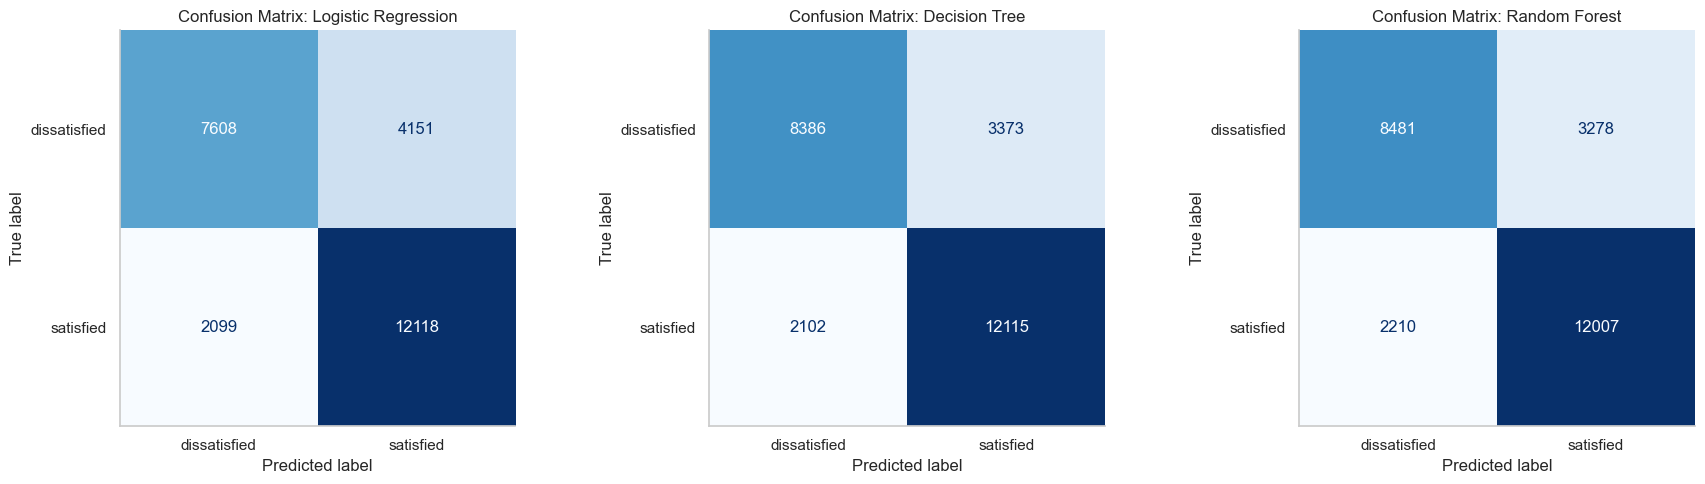

,Accuracy,F1-score,Log Loss,ROC-AUC
Modelo,,,,
Logistic Regression,0.7594,0.7560,0.5647,0.7718
Decision Tree,0.7892,0.7877,0.4746,0.8419
Random Forest,0.7887,0.7875,0.4730,0.8435



Modelo con mayor F1-score: Decision Tree  (F1 = 0.7877)


In [7]:
results_summary = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (model_name, model) in enumerate(best_models.items()):
    print(f"\n{model_name}")
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred
        
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    loss = log_loss(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Log Loss: {loss:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['dissatisfied', 'satisfied']))
    
    results_summary.append({
        'Modelo': model_name,
        'Accuracy': acc,
        'F1-score': f1,
        'Log Loss': loss,
        'ROC-AUC': roc_auc
    })
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=['dissatisfied', 'satisfied']
    )
    disp.plot(cmap='Blues', ax=axes[i], colorbar=False)
    axes[i].set_title(f"Confusion Matrix: {model_name}")
    axes[i].grid(False)

plt.tight_layout()
plt.show()

df_results = pd.DataFrame(results_summary).set_index('Modelo')
display(df_results.style.background_gradient(cmap='Blues', axis=0).format('{:.4f}'))

best_model_name = df_results['F1-score'].idxmax()
print(f"\nModelo con mayor F1-score: {best_model_name}  (F1 = {df_results.loc[best_model_name, 'F1-score']:.4f})")

---
## Comparación de modelos

Calculando learning curve para Logistic Regression...
Calculando learning curve para Decision Tree...
Calculando learning curve para Random Forest...


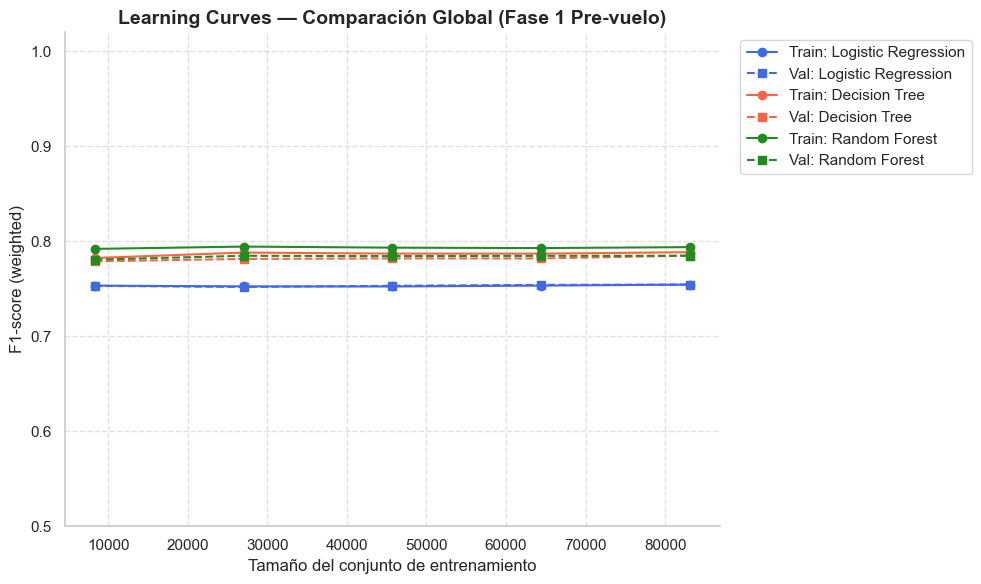

In [8]:
colores = ['royalblue', 'tomato', 'forestgreen']
train_sizes_pct = np.linspace(0.1, 1.0, 5)
lc_data = {}

for model_name, model in best_models.items():
    print(f"Calculando learning curve para {model_name}...")
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_train, y=y_train,
        train_sizes=train_sizes_pct,
        cv=cv_strat,
        scoring='f1_weighted',
        n_jobs=-1,
        random_state=42
    )
    lc_data[model_name] = {
        'sizes': train_sizes_abs,
        'train_mean': train_scores.mean(axis=1),
        'val_mean': val_scores.mean(axis=1)
    }

plt.figure(figsize=(10, 6))
for (model_name, data), color in zip(lc_data.items(), colores):
    plt.plot(data['sizes'], data['train_mean'], color=color, marker='o', label=f'Train: {model_name}')
    plt.plot(data['sizes'], data['val_mean'], color=color, marker='s', linestyle='--', label=f'Val: {model_name}')

plt.title('Learning Curves — Comparación Global (Fase 1 Pre-vuelo)', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('F1-score (weighted)')
plt.ylim(0.5, 1.02)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Rendimiento General**: Al evaluar los modelos utilizando únicamente variables demográficas y relacionadas al vuelo (previas a la experiencia), observamos que el **Random Forest** y el **Decision Tree** logran un F1-score cercano a 0.79, superando claramente a la Regresión Logística (0.76). Esto podría indicar que la relación entre las variables pre-vuelo y la satisfacción no es lineal: los árboles capturan interacciones entre features (por ejemplo, "viaje de negocios + clase business") que un modelo lineal simplemente no puede representar con la misma fidelidad.

**Análisis de la Métrica F1**: El F1-score equilibra la precisión y el recall. Un valor de 0.79 indica que el modelo tiene una capacidad razonable, pero limitada, para predecir la satisfacción del cliente basándose solo en variables previas al vuelo. La diferencia entre Decision Tree y Random Forest es casi insignificante en accuracy y F1 (0.0005 de diferencia). Se separan un poco en ROC-AUC (0.8419 vs. 0.8435) y Log Loss (0.4746 vs. 0.4730), donde el Random Forest lleva una ventaja. Esto tendría sentido: al promediar múltiples árboles, el ensamble produce probabilidades más calibradas que un árbol individual, lo que se refleja en métricas sensibles a la confianza de predicción como el Log Loss. Que el árbol individual iguale al ensamble en F1 podría indicar que con los hiperparámetros encontrados por el GridSearch, el árbol ya captura la mayor parte de la señal disponible en estas features.

**Hipótesis de Negocio**: Este "techo" de rendimiento (aprox. 79% de exactitud) sugiere fuertemente que las características demográficas y logísticas iniciales no son suficientes por sí solas para determinar la satisfacción del pasajero. La experiencia a bordo y los servicios post-compra (Fase 2) son probablemente los verdaderos determinantes de la satisfacción final.

---
## Importancia de variables - Random Forest

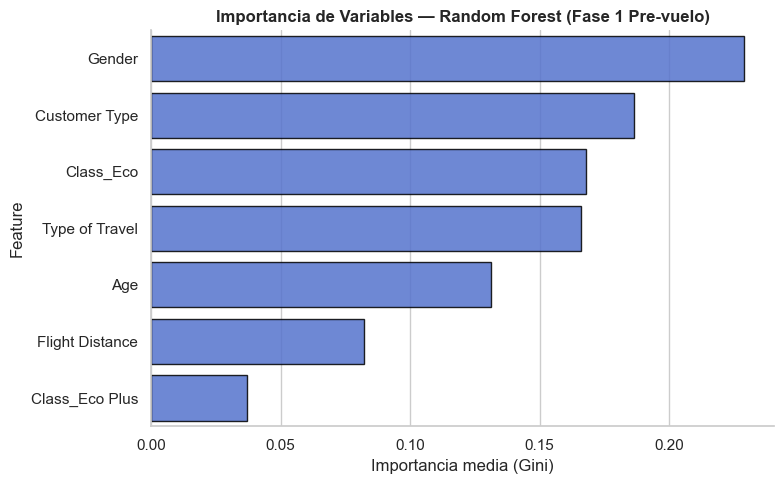

,Feature,Importance
0,Gender,0.229107
1,Customer Type,0.186474
2,Class_Eco,0.167975
3,Type of Travel,0.166152
4,Age,0.131208
5,Flight Distance,0.082169
6,Class_Eco Plus,0.036914


In [9]:
rf_pipeline = best_models['Random Forest']
rf_clf = rf_pipeline.named_steps['clf']
preprocessor_fit = rf_pipeline.named_steps['preprocessor']

ohe_feature_names = (
    preprocessor_fit
    .named_transformers_['ohe_class']
    .get_feature_names_out(ONEHOT_FEATURES)
    .tolist()
)

passthrough_names = ['Gender', 'Customer Type', 'Type of Travel']
all_feature_names = NUMERIC_FEATURES + ohe_feature_names + passthrough_names

importances = rf_clf.feature_importances_
feat_imp_df = (pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=feat_imp_df, y='Feature', x='Importance', color='royalblue', alpha=0.85, edgecolor='black', ax=ax)
ax.set_title('Importancia de Variables — Random Forest (Fase 1 Pre-vuelo)', fontweight='bold', fontsize=12)
ax.set_xlabel('Importancia media (Gini)')
plt.tight_layout()
plt.show()

display(feat_imp_df)

Gender encabeza el ranking con 0.229, por delante de variables que intuitivamente parecerían más determinantes como el tipo de cliente o la clase de cabina. Esto no significa necesariamente que el género cause satisfacción o insatisfacción, sino que en este dataset el género estaría correlacionado con algún patrón sistemático de respuesta, quizás porque ciertos segmentos de género se concentran más en determinados tipos de viaje o clases de cabina. 

Customer Type (0.187) y Class_Eco (0.168) ocupan el segundo y tercer lugar, lo que tiene más lógica intuitiva. Un pasajero leal probablemente tiene expectativas y experiencias base distintas a un pasajero ocasional, y viajar en economy es estructuralmente diferente a hacerlo en business. El hecho de que `Class_Eco` aparezca antes que `Class_Eco Plus` (0.037) sugiere que la distinción relevante para el modelo es principalmente entre economy y business (la categoría intermedia aportaría mucha menos señal).

Type of Travel (0.166) está prácticamente empatado con Class_Eco, lo que refuerza la idea de que el perfil del viajero de negocios vs. personal es uno de los segmentadores más fuertes disponibles en esta fase.

El ranking sugiere que el modelo pre-vuelo está operando principalmente como un segmentador de perfiles de pasajero: distingue razonablemente bien entre un cliente frecuente de business que viaja por trabajo y un pasajero ocasional de economy en viaje personal. Eso explica tanto su utilidad como su techo de rendimiento, una vez que se agota la señal del perfil, el modelo no tiene más información para afinar la predicción. Lo que le falta, y que el Modelo Post-Vuelo incorporará, es precisamente lo que ocurre durante el vuelo.

---
## Análisis undefitting y overfitting

Los tres modelos convergen en una zona de rendimiento moderado (~0.75–0.79 de F1) tanto en entrenamiento como en test. Que el Random Forest, el modelo con mayor capacidad expresiva de los tres, no logre superar ese umbral es una señal de que el límite no está en la complejidad del algoritmo, sino en la información disponible.

Con solo variables pre-vuelo, todos los modelos estarían operando con alto sesgo: no es que estén sub-entrenados o mal configurados, sino que las features simplemente no contienen señal suficiente para separar satisfechos de insatisfechos con mayor precisión. Podría decirse que el underfitting aquí no es un problema de modelado, es un problema de definición del problema. Predecir satisfacción sin saber nada de la experiencia a bordo es inherentemente difícil, y los modelos están reflejando esa dificultad.

### Overfitting

Las diferencias entre F1 en CV train y F1 en test son mínimas en los tres casos (0.002–0.003). Esto indica que los modelos generalizan bien dentro del espacio de features disponible, no están memorizando ruido del entrenamiento.

En el caso del Decision Tree, los árboles de decisión sin restricciones son notoriamente propensos al overfitting, pero los hiperparámetros encontrados por el GridSearch (`min_samples_split`, `min_samples_leaf`, `max_depth`) funcionaron como regularizadores efectivos. El árbol aprendió patrones generalizables, no outliers.

Para el Random Forest la ausencia de overfitting es más esperada, el mecanismo de bagging y la restricción `max_features='sqrt'` están diseñados específicamente para reducir la varianza del ensamble. Que el árbol individual iguale al ensamble en generalización sugiere que, en este espacio de features, agregar más árboles no aporta reducción de varianza adicional porque la varianza ya era baja desde el árbol solo.